In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

#coffee_data = pd.read_csv(r"..\data\reduced_data_num.csv")
coffee_data = pd.read_csv(r"..\data\reduced_data_bin.csv")

# Create the target column
#coffee_data['target'] = coffee_data['caffeine_class'].map(lambda x: 0 if x == 'Absent' else 1)

# Store the column names before scaling
column_names = coffee_data.drop(columns=['caffeine_class', 'caffeine_percent']).columns

# scaler = StandardScaler()
# X_scaled_std = scaler.fit_transform(coffee_data.drop(columns=['caffeine_class', 'caffeine_percent']))
# X = X_scaled_std.copy()  # Your scaled data
X = coffee_data.drop(columns=["caffeine_class", "caffeine_percent"])
y = coffee_data['caffeine_class']

In [2]:
X_all = X.copy()
y_all = y.copy()

In [7]:
import pandas as pd
import numpy as np
#from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# For demonstration: use X_all and y_all already in environment
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Pipeline with SMOTE oversampling + RandomForest
pipeline = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("clf", RandomForestClassifier(n_estimators=200, random_state=42))
])

# Cross-validated predictions and probabilities
y_pred = cross_val_predict(pipeline, X_all, y_all, cv=cv)
y_proba = cross_val_predict(pipeline, X_all, y_all, cv=cv, method="predict_proba")[:, 1]

# Compute metrics
metrics = {
    "Accuracy": accuracy_score(y_all, y_pred),
    "Precision (pos)": precision_score(y_all, y_pred),
    "Recall (pos)": recall_score(y_all, y_pred),
    "F1 Score": f1_score(y_all, y_pred),
    "ROC AUC": roc_auc_score(y_all, y_proba)
}

# Confusion matrix
cm = confusion_matrix(y_all, y_pred)

# Detailed classification report
report = classification_report(y_all, y_pred, target_names=["No Caffeine","Caffeine"], output_dict=True)
report_df = pd.DataFrame(report).transpose()

# Display summary
summary_df = pd.DataFrame.from_dict(metrics, orient="index", columns=["Value"])
print("SMOTE + RFC Classification Metrics", summary_df)

# Display confusion matrix
cm_df = pd.DataFrame(cm, index=["Actual 0","Actual 1"], columns=["Pred 0","Pred 1"])

# Display classification report
print("SMOTE + RFC Classification Report", report_df.round(3))
cm

SMOTE + RFC Classification Metrics                     Value
Accuracy         0.813333
Precision (pos)  0.542373
Recall (pos)     0.680851
F1 Score         0.603774
ROC AUC          0.861119
SMOTE + RFC Classification Report               precision  recall  f1-score  support
No Caffeine       0.910   0.848     0.878  356.000
Caffeine          0.542   0.681     0.604   94.000
accuracy          0.813   0.813     0.813    0.813
macro avg         0.726   0.765     0.741  450.000
weighted avg      0.833   0.813     0.821  450.000


array([[302,  54],
       [ 30,  64]])

In [13]:
import pandas as pd

# Replace the path below with the full path to your column_mapping.csv file
file_path = r'../input/column_mapping.csv'  # e.g., 'C:/Users/YourUsername/Documents/column_mapping.csv'

# Read the CSV file into a DataFrame
column_mapping = pd.read_csv(file_path)

name_mapping = dict(zip(column_mapping['new_name'], column_mapping['long_name']))

X_named = X_all.rename(columns=name_mapping)

 97%|=================== | 877/900 [00:16<00:00]       

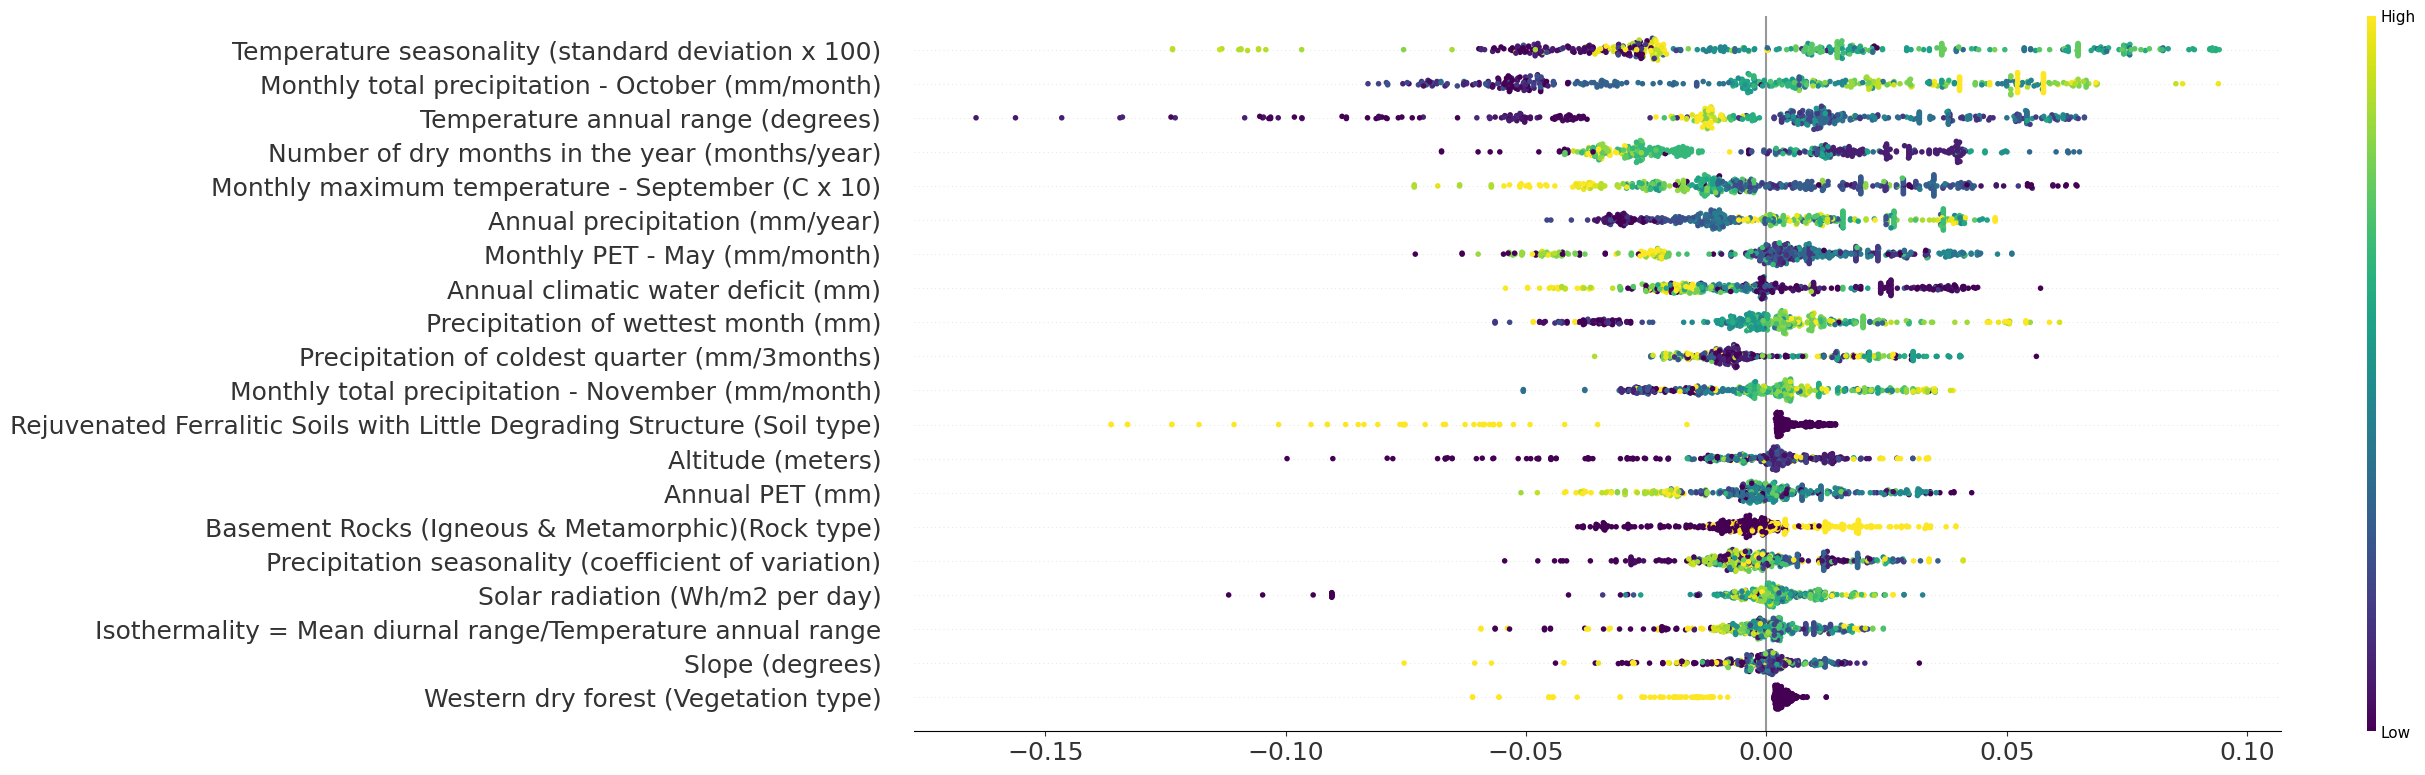

In [14]:
import shap
import matplotlib.pyplot as plt

# Fit the pipeline on all data
pipeline.fit(X_all, y_all)

# Build the SHAP explainer
explainer = shap.TreeExplainer(
    pipeline.named_steps["clf"],      # the RandomForestClassifier
    data        = X_all,
    model_output="probability",
    feature_perturbation="interventional"
)

# 1) Compute SHAP values (3‑D array for binary classifier)
sv = explainer.shap_values(X_all)   # shape = (450, 88, 2)

# 2) Extract class‑1 matrix
shap_vals_pos = sv[:, :, 1]         # now shape = (450, 88)

# 3) Verify it matches your feature matrix
assert shap_vals_pos.shape == X_named.shape, (
    f"SHAP {shap_vals_pos.shape} vs data {X_named.shape}"
)

# 4) Plot
# import shap
# shap.summary_plot(
#     shap_vals_pos,
#     X_named,
#     plot_size=(14, 6),
#     cmap="viridis"
# )
plt.figure(figsize=(14, 8))  # Adjust figure size for a wider plot
shap.summary_plot(shap_vals_pos, X_named, plot_size=(24, 8), show=False, cmap='viridis')
#plt.xlim(-0.02, 0.02)  # Expand x-axis limits to better view values around 0

fig = plt.gcf()
for ax in fig.axes:
    if 'colorbar' in ax.get_label().lower():
        colorbar = ax  # Identify the color bar axis
        colorbar.set_ylabel('')  # Remove the label from the color bar

#plt.title('SHAP Summary Plot')
plt.xlabel('')
plt.ylabel('')
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.show()

Without SMOTE

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

final_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)

print(classification_report(y_test, y_pred, digits=4))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

           0     0.9028    0.9155    0.9091        71
           1     0.6667    0.6316    0.6486        19

    accuracy                         0.8556        90
   macro avg     0.7847    0.7735    0.7789        90
weighted avg     0.8529    0.8556    0.8541        90

[[65  6]
 [ 7 12]]


In [4]:
import pandas as pd

# Replace the path below with the full path to your column_mapping.csv file
file_path = r'../input/column_mapping.csv'  # e.g., 'C:/Users/YourUsername/Documents/column_mapping.csv'

# Read the CSV file into a DataFrame
column_mapping = pd.read_csv(file_path)

name_mapping = dict(zip(column_mapping['new_name'], column_mapping['long_name']))

# Replace feature names in the SHAP summary plot data
X_train_renamed = X_train.rename(columns=name_mapping)


c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


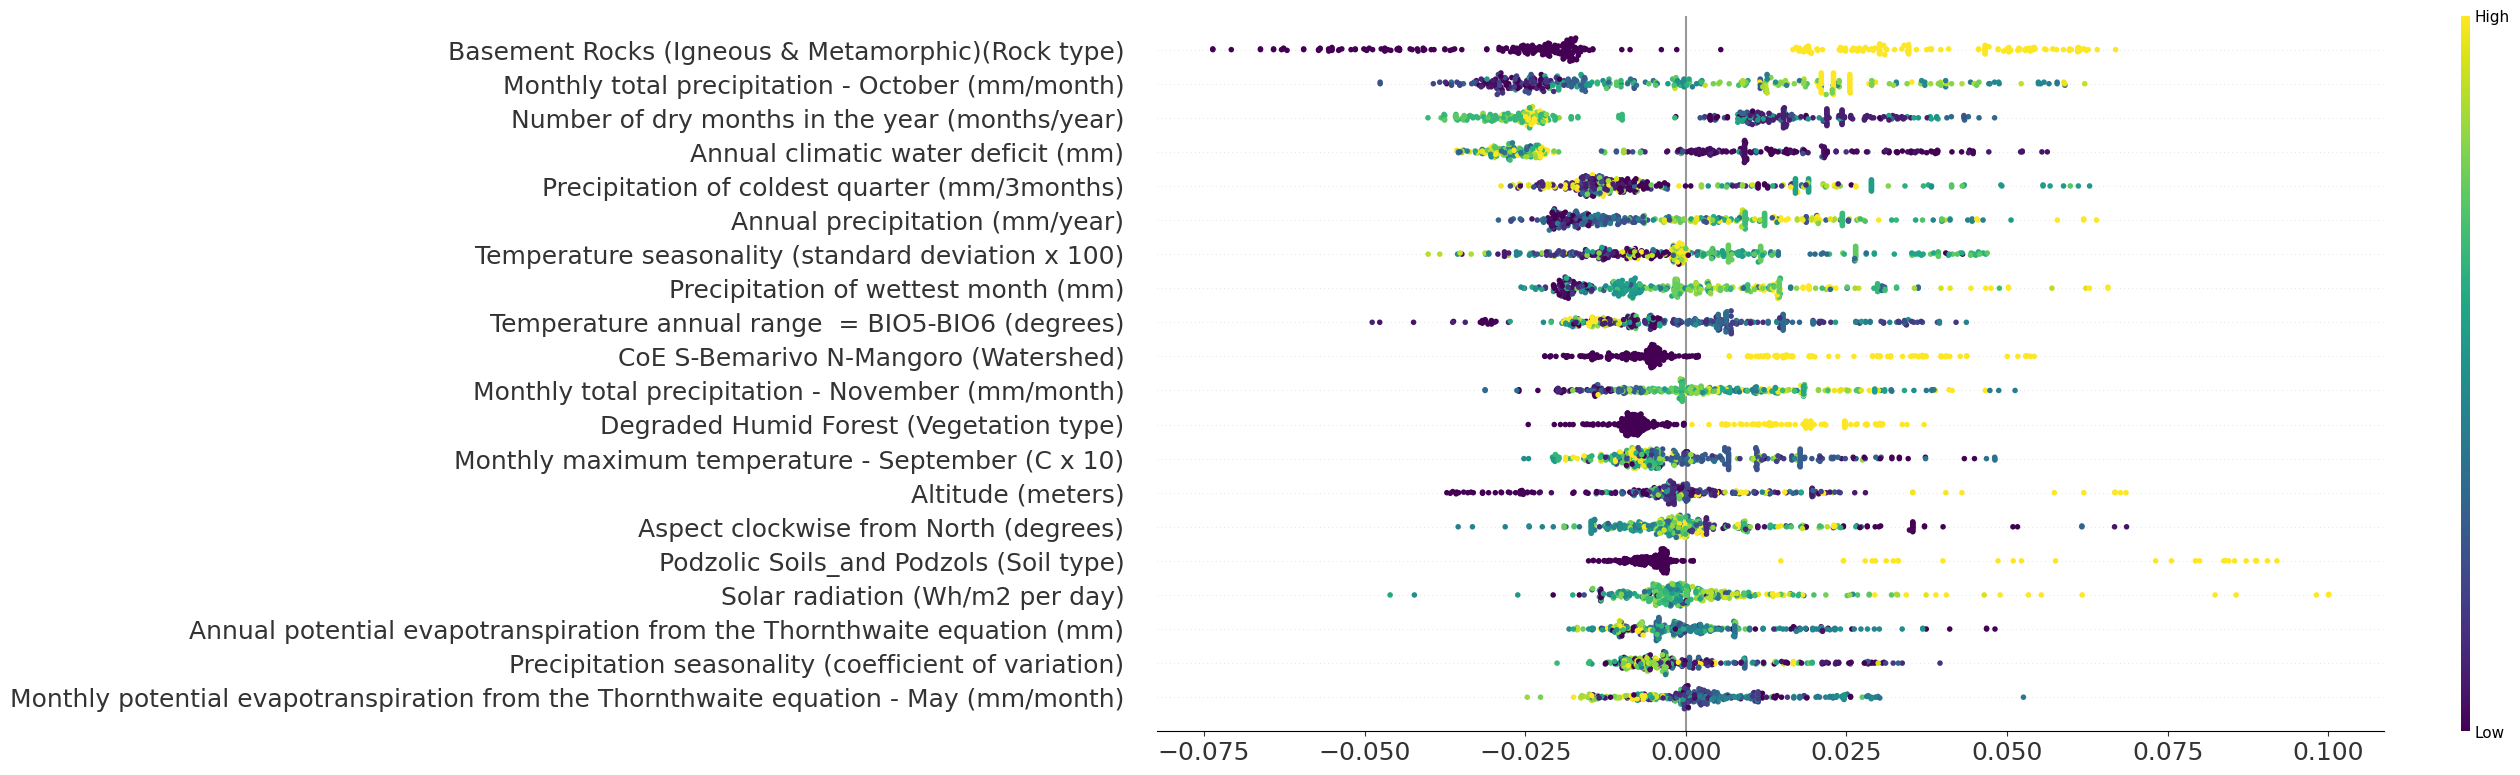

In [5]:
import shap
import matplotlib.pyplot as plt

# No need to manually specify feature_perturbation — let SHAP auto-handle
explainer = shap.TreeExplainer(final_model)

# Use a representative sample or full training data if memory allows
shap_values = explainer.shap_values(X_train_renamed)

# Plot for class 1 (assuming binary classification: [class 0, class 1])

shap_values_class1 = shap_values[:, :, 1]  # shape = (360, 88)

plt.figure(figsize=(14, 8))  # Adjust figure size for a wider plot
shap.summary_plot(shap_values_class1, X_train_renamed, plot_size=(24, 8), show=False, cmap='viridis')
#plt.xlim(-0.02, 0.02)  # Expand x-axis limits to better view values around 0

fig = plt.gcf()
for ax in fig.axes:
    if 'colorbar' in ax.get_label().lower():
        colorbar = ax  # Identify the color bar axis
        colorbar.set_ylabel('')  # Remove the label from the color bar

#plt.title('SHAP Summary Plot')
plt.xlabel('')
plt.ylabel('')
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.show()


